In [1]:
# Cornell notes — three densities (regular / extra / super).
# Lined paper PLUS a vertical cue-column divider (~25% from left) and a
# horizontal summary-band divider (~20% from bottom). Both dividers land
# on lattice lines so everything is pixel-aligned.
# Per-density (cue_col, summary_row) chosen so the cue column is closest
# to 25% of the usable width and the summary band is closest to 20% of
# the usable height — same target, snapped to each density's lattice.
# Output: ../output/cornell/{cornell,extra-cornell,super-cornell}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, hline, vline, ELEM_SIZE,
    grid_counts, lattice_x, lattice_y,
    output_path, variant_name, DENSITIES,
)

MODE = "cornell"

# Lattice index of the cue-column vertical divider and summary-row
# horizontal divider, per density. Snapped to nearest lattice line.
DIVIDERS = {
    "regular": (8,  34),   # cue 2000 px (24.2%), summary at 80.9%
    "extra":   (14, 56),   # cue 2100 px (25.4%), summary at 79.9%
    "super":   (17, 67),   # cue 2125 px (25.7%), summary at 79.7%
}

In [2]:
def render_cornell(spacing, cue_col, summary_row):
    """Lined background + vertical cue divider + horizontal summary divider.
    Cue divider runs from the j=0 horizontal line down to the j=summary_row
    line (extending into both endpoints so corners look solid)."""
    img = blank_page()
    n_x, n_y = grid_counts(spacing)
    for j in range(n_y):
        hline(img, lattice_y(j, spacing))
    vline(
        img,
        lattice_x(cue_col, spacing),
        top=lattice_y(0, spacing),
        bottom=lattice_y(summary_row, spacing) + ELEM_SIZE - 1,
    )
    draw_header(img)
    return img, n_x, n_y

regular  spacing=250px  34×43  cue@col 8  summary@row 34  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/cornell.png


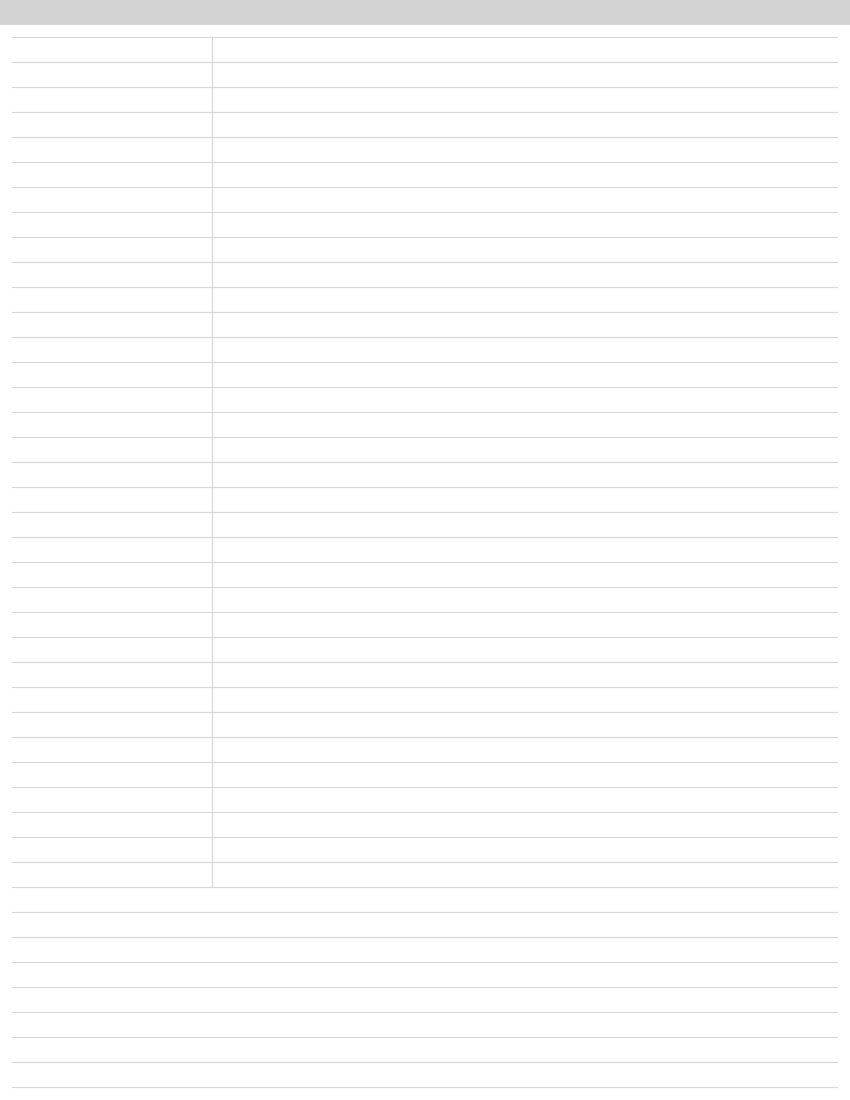

extra    spacing=150px  56×71  cue@col 14  summary@row 56  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/extra-cornell.png


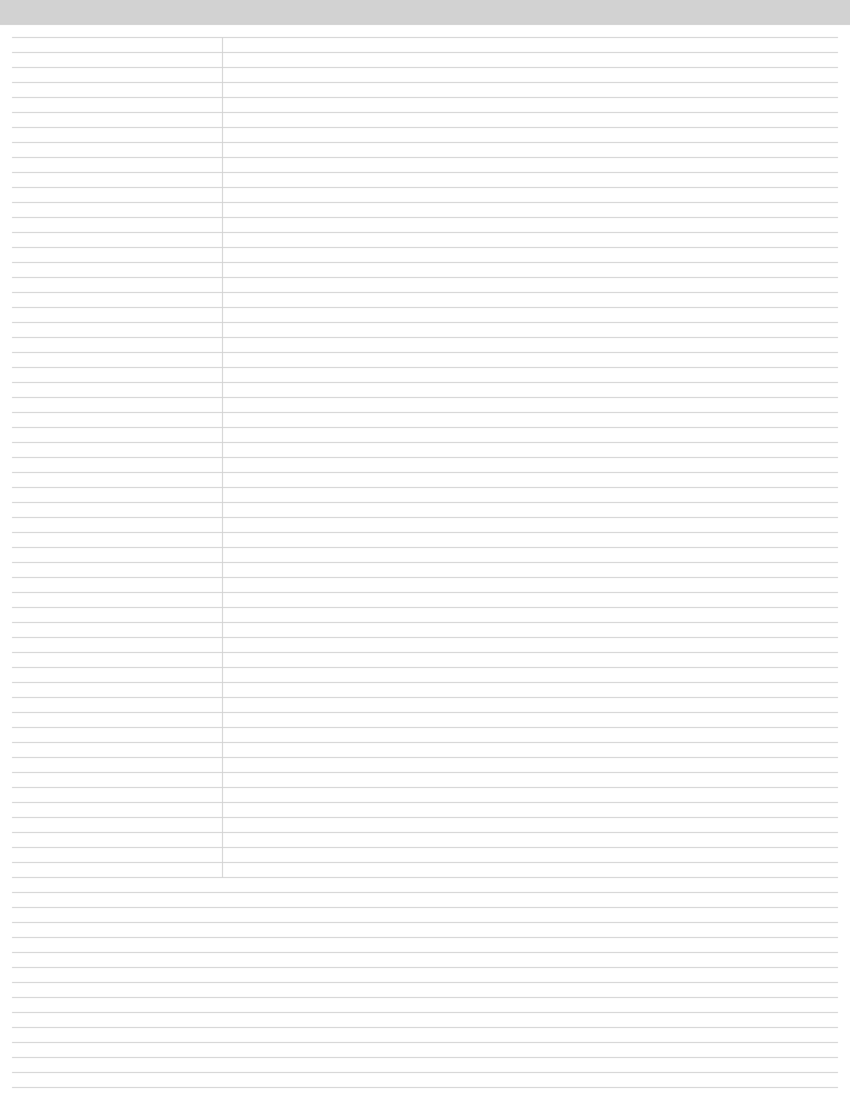

super    spacing=125px  67×85  cue@col 17  summary@row 67  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/super-cornell.png


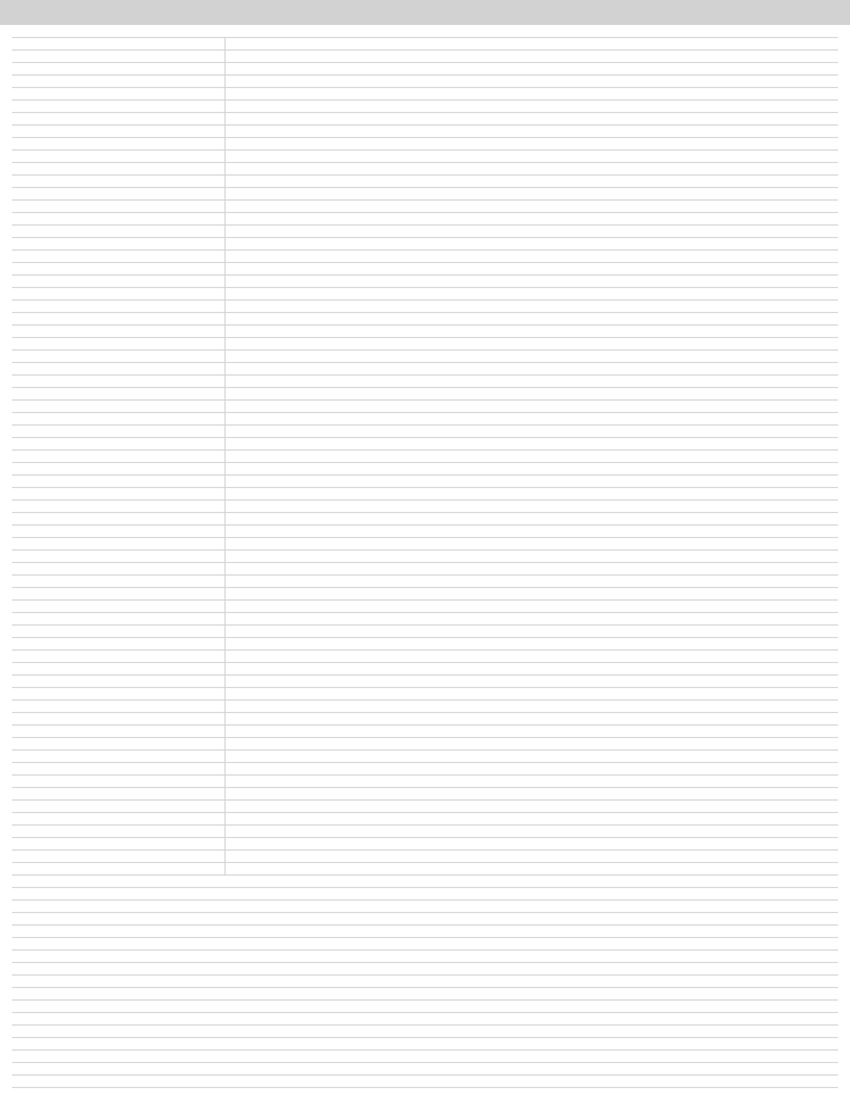

In [3]:
for density, spacing in DENSITIES.items():
    cue_col, summary_row = DIVIDERS[density]
    img, n_x, n_y = render_cornell(spacing, cue_col, summary_row)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} spacing={spacing:3d}px  {n_x}×{n_y}  "
        f"cue@col {cue_col}  summary@row {summary_row}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))